# Model Iteration Notebook 

In this notebook, we will focus on training and evaluating multiple machine learning models to classify emotions in transcribed television show data. 

The different secitons in this notebook will help demonstrate how different models perform on the same dataset and will provide insights into model selection and optimization. 

For every type of model and/or iteration that we did, we tracked the details in the model iteration file that you can find attached to the final assignment on Brightspace or here [Model Iteration File](link-here). In order to improve our models, we used (a selection of) traditional NLP features that we extracted in the ‘NLP Features’ task [NLP Features.ipynb notebook](NLP Features.ipynb). 



In [1]:
import sys
import os

# Get the directory of the current notebook (which is /notebooks/)
# and navigate up one level (to /project_root/) to find /src
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))

# Add the project root to the system path
if project_root not in sys.path:
    sys.path.append(project_root)

# Now you can import as if you were in the project root
# For /src/processing/features.py, the module is src.processing.features
from src.processing.features import FeatureEngine

c:\Users\rzvn1\.conda\envs\nlp_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[nltk_data] Downloading package universal_tagset to
[nltk_data]     C:\Users\rzvn1\AppData\Roaming\nltk_data...
[nltk_data]   Package universal_tagset is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\rzvn1\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\rzvn1\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\rzvn1\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\rzvn1

In [ ]:
import numpy as np
import pandas as pd
from typing import Dict
from collections import Counter

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.preprocessing import normalize

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Set Keras Backend to use PyTorch
os.environ["KERAS_BACKEND"] = "torch"
import keras
import torch 

print("Torch version:",torch.__version__)

print("Is CUDA enabled?",torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Torch version: 2.5.1
Is CUDA enabled? True


In [4]:
from keras import Model
from keras.models import load_model
from keras.layers import (Embedding, Dense, Concatenate,
                          SimpleRNN, LSTM, Input, Dropout)
from keras.callbacks import EarlyStopping
from keras.optimizers import AdamW, Adam
from keras.utils import to_categorical

In [5]:
import tensorflow as tf

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [6]:
# Emotion Map obtained from https://aclanthology.org/I17-1099/ --> readme.txt
EMOTION_MAP: Dict[int, str] = {
    0: "neutral", 1: "anger", 2: "disgust", 3: "fear",
    4: "happiness", 5: "sadness", 6: "surprise"
}

In [7]:
df_concat = pd.read_csv(r"..\Data\CSV\sentiment_data\final_dataset.csv")

### Data preparation for scikit-learn

In [8]:
scikit_data = []
# Get unique emotions
unique_emotions = df_concat['Emotion'].unique()

# For each unique emotion, add 350 different rows
for emotion in unique_emotions:
    # Get all rows with this emotion
    emotion_rows = df_concat[df_concat['Emotion'] == emotion]
    
    # Sample 350 rows (with replacement if there are fewer than 350 available)
    sampled_rows = emotion_rows.sample(n=700, replace=True, random_state=42)
    
    # Add to the list
    scikit_data.append(sampled_rows)

# Create new dataframe by concatenating all sampled rows
scikit_data = pd.concat(scikit_data, ignore_index=True)

scikit_data['Emotion_ID'] = scikit_data['Emotion_ID'].astype(int)

scikit_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4900 entries, 0 to 4899
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  4900 non-null   int64 
 1   Sentence    4900 non-null   object
 2   Emotion     4900 non-null   object
 3   Emotion_ID  4900 non-null   int32 
dtypes: int32(1), int64(1), object(2)
memory usage: 134.1+ KB


In [9]:
scikit_data['Sentence'].nunique()
scikit_data.drop_duplicates(subset=['Sentence'], inplace=True)

In [10]:
features = FeatureEngine()
results = features.create_features(transcript_df_input=scikit_data, output_path=None)

Training Word2Vec model...
Training complete.


In [11]:
scikit_df = results.copy()

In [12]:
scikit_df.head()

,Unnamed: 0,Sentence,Emotion,Emotion_ID,POS_tags,Sentiment,TF-IDF,word2vec_embedding,custom_word2vec_embedding,bert_embedding
0,131607,i think the fact that i am feeling a little ap...,fear,3,"[(i, NOUN), (think, VERB), (the, DET), (fact, ...",0.137500,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[-0.0067983773, 0.028879605, 0.0091975285, 0.0...","[-0.0042349068, 0.18589441, -0.019914303, 0.04...","[0.26444843, 0.39232564, 0.06754342, -0.534239..."
1,6835,i started feeling terrified,fear,3,"[(i, NOUN), (started, VERB), (feeling, VERB), ...",0.000000,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.030395508, 0.08758545, 0.0077209473, 0.0012...","[-0.07970527, 0.21832013, 0.049015936, 0.00631...","[0.12794185, 0.13075173, 0.14813915, -0.064277..."
2,330814,i feel for all of the victims and their famili...,fear,3,"[(i, NOUN), (feel, VERB), (for, ADP), (all, DE...",0.166667,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.010828191, 0.02356512, 0.010276101, 0.12585...","[0.07009932, 0.10871184, -0.03618733, 0.101628...","[-0.06701388, 0.14782472, 0.12844124, -0.26227..."
3,506845,I’m afraid of the dark.,fear,3,"[(I, PRON), (’, VERB), (m, ADJ), (afraid, NOUN...",-0.375000,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.1953125, 0.08569336, 0.13183594, 0.0579834,...","[-0.028786289, 0.00070031005, 0.016867759, 0.2...","[0.30258685, 0.33086362, -0.35033846, -0.45129..."
4,93206,i feel pretty shy about the students but i thi...,fear,3,"[(i, NOUN), (feel, VERB), (pretty, ADV), (shy,...",0.170833,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.029205322, 0.029956818, 0.04335022, 0.12544...","[-0.03798985, 0.08308216, -0.050341528, 0.1257...","[0.28519934, 0.10159663, 0.25914514, -0.241023..."


In [13]:
scikit_df = scikit_df.drop(columns=['Emotion', 'POS_tags','TF-IDF', 'Sentence','Unnamed: 0'])

In [14]:
scikit_df['Sentiment'] = scikit_df['Sentiment'].values.reshape(-1, 1)
scikit_df['word2vec_embedding'] = np.vstack(scikit_df['word2vec_embedding'].values)
scikit_df['bert_embedding'] = np.vstack(scikit_df['bert_embedding'].values)
scikit_df['custom_word2vec_embedding'] = np.vstack(scikit_df['custom_word2vec_embedding'].values)

In [15]:
scikit_df.head()

,Emotion_ID,Sentiment,word2vec_embedding,custom_word2vec_embedding,bert_embedding
0,3,0.137500,-0.006798,-0.004235,0.264448
1,3,0.000000,0.030396,-0.079705,0.127942
2,3,0.166667,0.010828,0.070099,-0.067014
3,3,-0.375000,0.195312,-0.028786,0.302587
4,3,0.170833,0.029205,-0.037990,0.285199


In [16]:
# Initialize empty dict for storing predictions
predictions = {}

### Logistic Regression

In [17]:
log_reg = LogisticRegression(max_iter=3000, penalty='elasticnet', random_state=42, solver='saga', l1_ratio=0.5)
X = scikit_df.drop(columns=['Emotion_ID'])
y = scikit_df['Emotion_ID']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

log_reg.fit(X_train, y_train)
y_pred = log_reg.predict(X_test)
predictions["Logistic Regression"] = y_pred

print(classification_report(y_test, y_pred, digits=3, target_names=EMOTION_MAP.values()))


              precision    recall  f1-score   support

     neutral      0.213     0.355     0.266       121
       anger      0.172     0.211     0.190       123
     disgust      0.297     0.268     0.281       142
        fear      0.000     0.000     0.000       158
   happiness      0.360     0.601     0.450       143
     sadness      0.193     0.239     0.214       138
    surprise      0.237     0.127     0.165       142

    accuracy                          0.252       967
   macro avg      0.210     0.257     0.224       967
weighted avg      0.208     0.252     0.220       967



c:\Users\rzvn1\.conda\envs\nlp_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\rzvn1\.conda\envs\nlp_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\rzvn1\.conda\envs\nlp_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0]

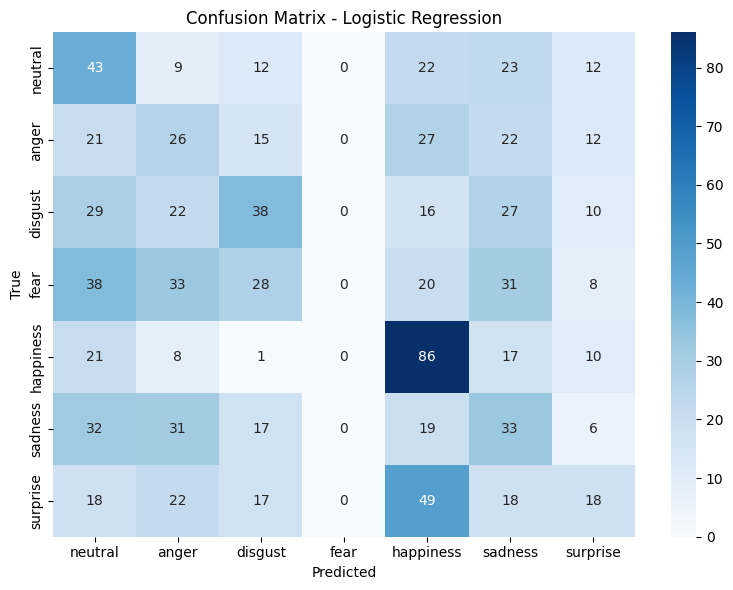

In [18]:
# Get predictions from log_reg
y_pred = log_reg.predict(X_test)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot heatmap
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[EMOTION_MAP[i] for i in range(len(EMOTION_MAP))],
            yticklabels=[EMOTION_MAP[i] for i in range(len(EMOTION_MAP))],
            ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confusion Matrix - Logistic Regression')
plt.tight_layout()
plt.show()

In [19]:
nb = GaussianNB(var_smoothing=2)
nb.fit(X_train, y_train)
y_pred = nb.predict(X_test)
predictions["Naive Bayes"] = y_pred

print(classification_report(y_test, y_pred,digits=3, target_names=EMOTION_MAP.values()))

              precision    recall  f1-score   support

     neutral      0.162     0.653     0.260       121
       anger      0.152     0.276     0.196       123
     disgust      0.636     0.099     0.171       142
        fear      0.000     0.000     0.000       158
   happiness      0.342     0.552     0.422       143
     sadness      0.000     0.000     0.000       138
    surprise      0.000     0.000     0.000       142

    accuracy                          0.213       967
   macro avg      0.185     0.226     0.150       967
weighted avg      0.184     0.213     0.145       967



c:\Users\rzvn1\.conda\envs\nlp_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\rzvn1\.conda\envs\nlp_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\rzvn1\.conda\envs\nlp_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0]

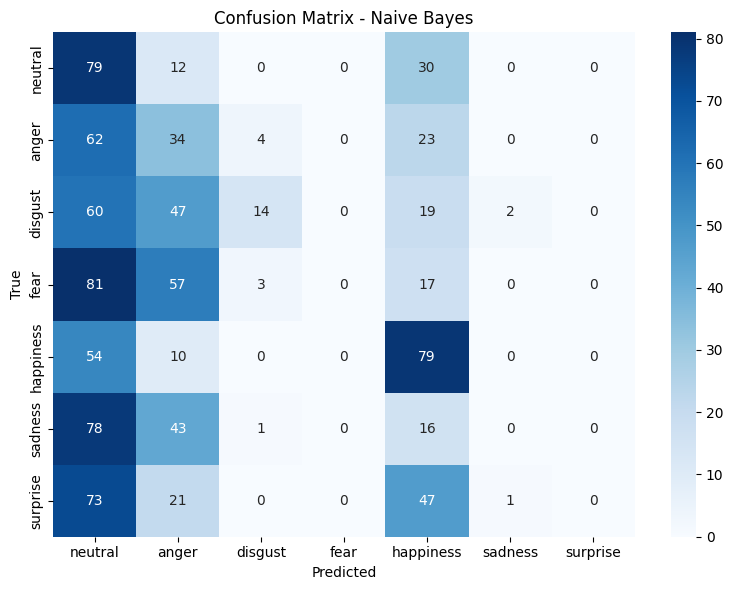

In [20]:
# Get predictions from Naive Bayes
y_pred = nb.predict(X_test)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot heatmap
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[EMOTION_MAP[i] for i in range(len(EMOTION_MAP))],
            yticklabels=[EMOTION_MAP[i] for i in range(len(EMOTION_MAP))],
            ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confusion Matrix - Naive Bayes')
plt.tight_layout()
plt.show()

In [21]:
svc = LinearSVC(penalty='l2', loss='squared_hinge', C=2000.0, multi_class='ovr', fit_intercept=True, random_state=42, dual=True, max_iter=30000)
svc.fit(X_train, y_train)

y_pred = svc.predict(X_test)
predictions["SVC"] = y_pred
print(classification_report(y_test, y_pred,digits=3, target_names=EMOTION_MAP.values()))

              precision    recall  f1-score   support

     neutral      0.217     0.298     0.251       121
       anger      0.184     0.187     0.185       123
     disgust      0.249     0.296     0.270       142
        fear      0.000     0.000     0.000       158
   happiness      0.290     0.664     0.403       143
     sadness      0.165     0.167     0.166       138
    surprise      0.175     0.049     0.077       142

    accuracy                          0.234       967
   macro avg      0.183     0.237     0.193       967
weighted avg      0.179     0.234     0.189       967



c:\Users\rzvn1\.conda\envs\nlp_env\lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\rzvn1\.conda\envs\nlp_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\rzvn1\.conda\envs\nlp_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\rzvn1\.conda\envs\nlp_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and bei

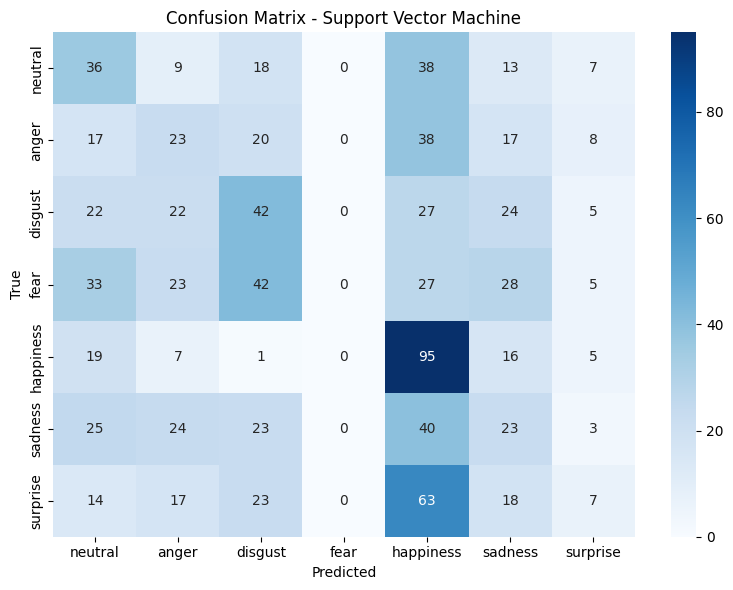

In [22]:
# Get predictions from Support Vector Machine
y_pred = svc.predict(X_test)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot heatmap
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[EMOTION_MAP[i] for i in range(len(EMOTION_MAP))],
            yticklabels=[EMOTION_MAP[i] for i in range(len(EMOTION_MAP))],
            ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confusion Matrix - Support Vector Machine')
plt.tight_layout()
plt.show()

In [23]:
TRUE_SKLEARN = y_test
SK_TEST = X_test

In [24]:
keras_data = []
# Get unique emotions
unique_emotions = df_concat['Emotion'].unique()

# For each unique emotion, add 350 different rows
for emotion in unique_emotions:
    # Get all rows with this emotion
    emotion_rows = df_concat[df_concat['Emotion'] == emotion]
    
    # Sample 350 rows (with replacement if there are fewer than 350 available)
    sampled_rows = emotion_rows.sample(n=1000, replace=True, random_state=42)
    
    # Add to the list
    keras_data.append(sampled_rows)

# Create new dataframe by concatenating all sampled rows
keras_data = pd.concat(keras_data, ignore_index=True)
keras_data['Emotion_ID'] = keras_data['Emotion_ID'].astype(int)

keras_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  7000 non-null   int64 
 1   Sentence    7000 non-null   object
 2   Emotion     7000 non-null   object
 3   Emotion_ID  7000 non-null   int32 
dtypes: int32(1), int64(1), object(2)
memory usage: 191.5+ KB


In [25]:
keras_data['Sentence'].nunique()
keras_data.drop_duplicates(subset=['Sentence'], inplace=True)

In [26]:
features = FeatureEngine()

keras_df = features.create_features(transcript_df_input=keras_data, output_path=None)

Training Word2Vec model...
Training complete.


In [27]:
keras_df.drop(columns='Unnamed: 0', inplace=True)

In [28]:
keras_df.head()

,Sentence,Emotion,Emotion_ID,POS_tags,Sentiment,TF-IDF,word2vec_embedding,custom_word2vec_embedding,bert_embedding
0,i think the fact that i am feeling a little ap...,fear,3,"[(i, NOUN), (think, VERB), (the, DET), (fact, ...",0.137500,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[-0.0067983773, 0.028879605, 0.0091975285, 0.0...","[-0.102925785, 0.11512933, 0.030736191, -0.044...","[0.26444843, 0.39232564, 0.06754342, -0.534239..."
1,i started feeling terrified,fear,3,"[(i, NOUN), (started, VERB), (feeling, VERB), ...",0.000000,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.030395508, 0.08758545, 0.0077209473, 0.0012...","[0.055477034, -0.13393866, -0.06020303, -0.188...","[0.12794185, 0.13075173, 0.14813915, -0.064277..."
2,i feel for all of the victims and their famili...,fear,3,"[(i, NOUN), (feel, VERB), (for, ADP), (all, DE...",0.166667,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.010828191, 0.02356512, 0.010276101, 0.12585...","[-0.03174401, 0.12016219, 0.01713704, -0.01281...","[-0.06701388, 0.14782472, 0.12844124, -0.26227..."
3,I’m afraid of the dark.,fear,3,"[(I, PRON), (’, VERB), (m, ADJ), (afraid, NOUN...",-0.375000,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.1953125, 0.08569336, 0.13183594, 0.0579834,...","[-0.018149061, -0.123968296, 0.117944926, 0.26...","[0.30258685, 0.33086362, -0.35033846, -0.45129..."
4,i feel pretty shy about the students but i thi...,fear,3,"[(i, NOUN), (feel, VERB), (pretty, ADV), (shy,...",0.170833,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.029205322, 0.029956818, 0.04335022, 0.12544...","[-0.10316928, 0.13550423, 0.050737835, 0.02624...","[0.28519934, 0.10159663, 0.25914514, -0.241023..."


In [29]:
keras_df = keras_df.drop(columns=['Emotion', 'POS_tags','TF-IDF'])

In [30]:
X = keras_df.drop(columns=['Emotion_ID'])
y = keras_df['Emotion_ID']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [31]:
X_train.shape, X_test.shape

((5498, 5), (1375, 5))

In [32]:
tokenizer = Tokenizer(filters='')
tokenizer.fit_on_texts(X_train['Sentence'])

In [33]:
V = len(tokenizer.word_index)
V

9924

In [34]:
train_tok = tokenizer.texts_to_sequences(X_train['Sentence'])
test_tok = tokenizer.texts_to_sequences(X_test['Sentence'])

In [35]:
train_padded = pad_sequences(train_tok,
              padding='post',
              maxlen=30)

test_padded = pad_sequences(test_tok,
              padding='post',
              maxlen=30)


In [36]:
X_train['Sentence_Tok'] = train_padded.tolist()
X_test['Sentence_Tok'] = test_padded.tolist()

In [37]:
X_train.drop(columns='Sentence', inplace=True)
X_test.drop(columns='Sentence', inplace=True)

In [38]:
y_train = to_categorical(y_train, num_classes=7)
y_test = to_categorical(y_test, num_classes=7)

In [39]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((5498, 5), (5498, 7), (1375, 5), (1375, 7))

In [40]:
X_train.head()

,Sentiment,word2vec_embedding,custom_word2vec_embedding,bert_embedding,Sentence_Tok
4688,0.20,"[0.029514018, 0.015031081, 0.016991835, 0.1229...","[-0.1384756, 0.15272664, 0.019190714, -0.03337...","[0.24796142, 0.15772775, 0.041748233, -0.34366...","[1, 5, 18, 2, 60, 1, 19, 24, 2, 677, 15, 63, 4..."
5693,0.00,"[0.07672119, -0.006591797, 0.04321289, 0.08046...","[-0.1383737, 0.23206776, -0.010152851, -0.1643...","[0.086479805, -0.015461787, -0.3460927, 0.2454...","[128, 25, 1542, 4162, 170, 2, 884, 40, 0, 0, 0..."
2134,0.00,"[0.04073819, 0.02465959, 0.081809305, 0.135409...","[0.048609983, 0.050951492, 0.04979581, 0.04466...","[0.037790444, -0.009430461, 0.2575016, -0.2049...","[1, 33, 4163, 32, 2807, 1, 252, 75, 2808, 973,..."
252,0.00,"[0.012212117, 0.040827435, -0.017425537, 0.117...","[-0.13868202, 0.1311219, -0.1018688, -0.027542...","[-0.074894674, 0.30284852, -0.14308092, -0.360...","[1, 27, 90, 4165, 4, 4166, 313, 5, 1, 27, 98, ..."
2666,0.35,"[0.033184346, -0.00034038836, 0.024799053, 0.1...","[-0.11949326, 0.06872231, 0.041889563, 0.03947...","[-0.1280152, 0.06455885, 0.061843384, 0.077798...","[1, 5, 63, 1090, 3, 30, 322, 3, 4167, 4168, 13..."


In [41]:
X_train_toks = X_train['Sentence_Tok']
X_test_toks = X_test['Sentence_Tok']

In [42]:
X_train_toks =  np.array(X_train_toks.tolist())
X_test_toks = np.array(X_test_toks.tolist()) 

In [43]:
X_train_features = np.hstack([
    np.stack(X_train["word2vec_embedding"].to_numpy()),
    np.stack(X_train["bert_embedding"].to_numpy())
])

X_test_features = np.hstack([
    np.stack(X_test["word2vec_embedding"].to_numpy()),
    np.stack(X_test["bert_embedding"].to_numpy())
])

In [44]:
X_train_toks.shape, X_test_toks.shape

((5498, 30), (1375, 30))

### RNN Model

#### One recurrent layer

In [45]:
tokens_input = Input(shape=(30,), name="tokens_input")
x = Embedding(input_dim=V+1, output_dim=128)(tokens_input)
x = SimpleRNN(128, activation="tanh", return_sequences=False)(x)  # final hidden state

# 4. Classification head
dense = Dense(64, activation="relu", kernel_regularizer="l2")(x)
dense = Dense(128, activation="relu", kernel_regularizer="l2")(dense)
dense = Dropout(0.4)(dense)
output = Dense(7, activation="softmax")(dense)

# 5. Build model
model = Model(inputs=tokens_input, outputs=output, name='SimpleRNN-v0')
model.compile(optimizer=Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
# Monitors the validation loss and stops after 3 epochs with no improvement
early_stopping = EarlyStopping(monitor='val_accuracy', patience=5, verbose=0, restore_best_weights=True)

with device:
    history = model.fit(
        X_train_toks, y_train,
        validation_data=(X_test_toks, y_test),
        epochs=100,
        batch_size=64,
        verbose=0,
        callbacks=[early_stopping]
    )

Epoch 1/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.1828 - loss: 3.5262 - val_accuracy: 0.2575 - val_loss: 3.3812
Epoch 2/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.2699 - loss: 3.1877 - val_accuracy: 0.2865 - val_loss: 2.9928
Epoch 3/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.3188 - loss: 2.8995 - val_accuracy: 0.3367 - val_loss: 2.7888
Epoch 4/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.3770 - loss: 2.6637 - val_accuracy: 0.3695 - val_loss: 2.6396
Epoch 5/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.4020 - loss: 2.4688 - val_accuracy: 0.4109 - val_loss: 2.5257
Epoch 6/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4456 - loss: 2.2795 - val_accuracy: 0.4240 - val_loss: 2.3977
Epoch 7/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5027 - loss: 2.0771 - val_accuracy: 0.4364 - val_loss: 2.2961
Epoch 8/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5404 - loss: 1.8816 - val_accuracy: 0.4524 - 

In [47]:
try:
    model = load_model(r"keras-models\SimpleRNN-v0.keras")
except:
    pass

In [48]:
# Evaluate the model on the test set
loss, accuracy = model.evaluate(X_test_toks, y_test, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

Test Loss: 2.1374
Test Accuracy: 0.5527


In [49]:
# Step 1: Get predictions
y_pred_probs = model.predict(X_test_toks)

# Step 2: Convert probabilities to class labels
y_pred = np.argmax(y_pred_probs, axis=1)

# Step 3: Convert y_test if it's one-hot encoded
if y_test.ndim > 1 and y_test.shape[1] > 1:
    y_true = np.argmax(y_test, axis=1)
else:
    y_true = y_test

predictions["SimpleRNN-v0"] = y_pred

# Step 4: Generate classification report
print(classification_report(y_true, y_pred, digits=3))

43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
              precision    recall  f1-score   support

           0      0.681     0.697     0.689       208
           1      0.543     0.575     0.559       186
           2      0.566     0.563     0.565       174
           3      0.584     0.547     0.565       203
           4      0.539     0.480     0.508       200
           5      0.535     0.498     0.516       213
           6      0.429     0.508     0.465       191

    accuracy                          0.553      1375
   macro avg      0.554     0.553     0.552      1375
weighted avg      0.555     0.553     0.553      1375



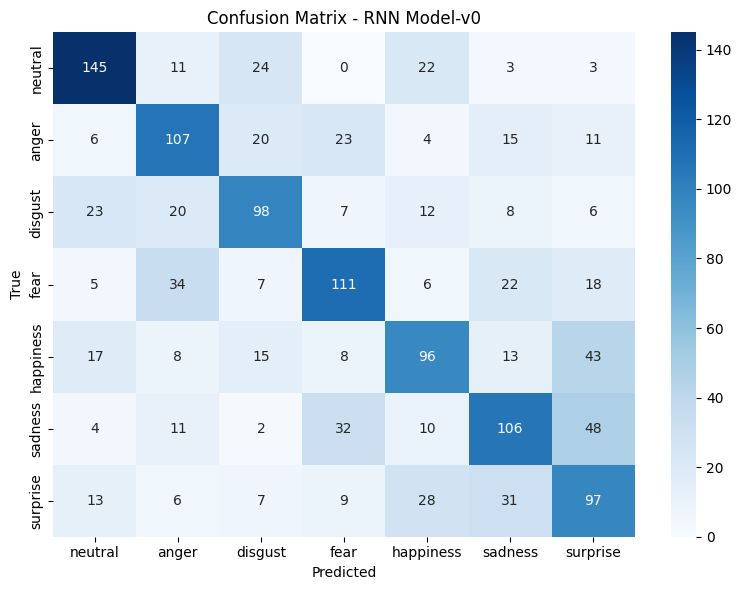

In [50]:
# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot heatmap
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[EMOTION_MAP[i] for i in range(len(EMOTION_MAP))],
            yticklabels=[EMOTION_MAP[i] for i in range(len(EMOTION_MAP))],
            ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confusion Matrix - RNN Model-v0')
plt.tight_layout()
plt.show()

#### Two recurrent layers

In [51]:
tokens_input = Input(shape=(30,), name="tokens_input")
x = Embedding(input_dim=V+1, output_dim=128)(tokens_input)
x = SimpleRNN(128, activation="tanh", return_sequences=True)(x)
x = SimpleRNN(128, activation="tanh", return_sequences=False)(x)  # final hidden state

# 4. Classification head
dense = Dense(64, activation="relu", kernel_regularizer="l2")(x)
dense = Dense(128, activation="relu", kernel_regularizer="l2")(dense)
dense = Dropout(0.4)(dense)
output = Dense(7, activation="softmax")(dense)

# 5. Build model
model = Model(inputs=tokens_input, outputs=output, name="SimpleRNN-v1")
model.compile(optimizer=Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
# Monitors the validation loss and stops after 3 epochs with no improvement
early_stopping = EarlyStopping(monitor='val_accuracy', patience=5, verbose=0, restore_best_weights=True)

with device:
    history = model.fit(
        X_train_toks, y_train,
        validation_data=(X_test_toks, y_test),
        epochs=100,
        batch_size=64,
        verbose=0,
        callbacks=[early_stopping]
    )

Epoch 1/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.1686 - loss: 3.5756 - val_accuracy: 0.2400 - val_loss: 3.4515
Epoch 2/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.2792 - loss: 3.2786 - val_accuracy: 0.3055 - val_loss: 3.0751
Epoch 3/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.3432 - loss: 2.9885 - val_accuracy: 0.3585 - val_loss: 2.8728
Epoch 4/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.3898 - loss: 2.7764 - val_accuracy: 0.3636 - val_loss: 2.7401
Epoch 5/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.4356 - loss: 2.5843 - val_accuracy: 0.4255 - val_loss: 2.6149
Epoch 6/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.4882 - loss: 2.3894 - val_accuracy: 0.4451 - val_loss: 2.4854
Epoch 7/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5669 - loss: 2.1641 - val_accuracy: 0.4931 - val_loss: 2.3147
Epoch 8/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6491 - loss: 1.9112 - val_accuracy: 0.

In [53]:
try:
    model = load_model(r"keras-models\SimpleRNN-v1.keras")
except:
    pass

In [54]:
# Evaluate the model on the test set
loss, accuracy = model.evaluate(X_test_toks, y_test, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

Test Loss: 2.1685
Test Accuracy: 0.5964


In [55]:
# Step 1: Get predictions
y_pred_probs = model.predict(X_test_toks)

# Step 2: Convert probabilities to class labels
y_pred = np.argmax(y_pred_probs, axis=1)

# Step 3: Convert y_test if it's one-hot encoded
if y_test.ndim > 1 and y_test.shape[1] > 1:
    y_true = np.argmax(y_test, axis=1)
else:
    y_true = y_test

predictions["SimpleRNN-v1"] = y_pred

# Step 4: Generate classification report
print(classification_report(y_true, y_pred, digits=3))

43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
              precision    recall  f1-score   support

           0      0.781     0.788     0.785       208
           1      0.508     0.527     0.517       186
           2      0.513     0.586     0.547       174
           3      0.610     0.586     0.598       203
           4      0.535     0.495     0.514       200
           5      0.551     0.582     0.566       213
           6      0.679     0.597     0.635       191

    accuracy                          0.596      1375
   macro avg      0.597     0.595     0.595      1375
weighted avg      0.599     0.596     0.597      1375



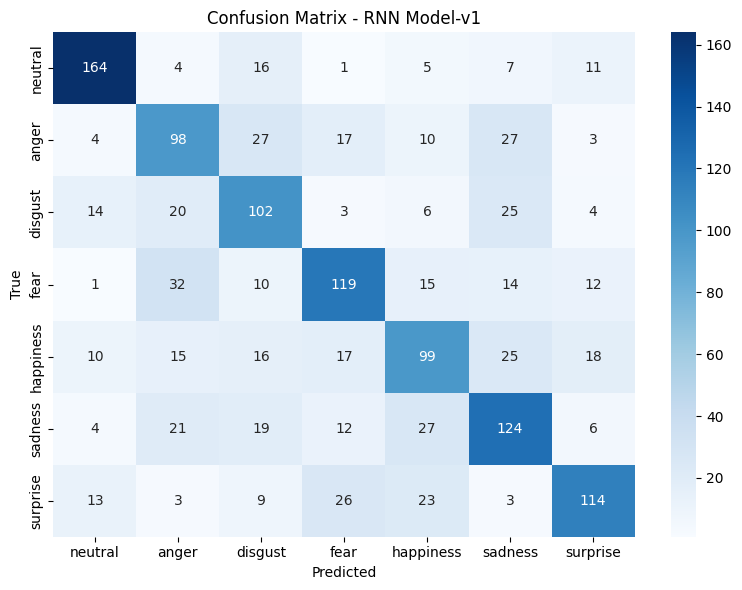

In [56]:
# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot heatmap
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[EMOTION_MAP[i] for i in range(len(EMOTION_MAP))],
            yticklabels=[EMOTION_MAP[i] for i in range(len(EMOTION_MAP))],
            ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confusion Matrix - RNN Model-v1')
plt.tight_layout()
plt.show()

### LSTM Model

#### One recurrent layer

In [57]:
tokens_input = Input(shape=(30,), name="tokens_input")
x = Embedding(input_dim=V+1, output_dim=128)(tokens_input)
x = LSTM(128, activation="tanh", return_sequences=False)(x)  # final hidden state
# 4. Classification head
dense = Dense(64, activation="relu", kernel_regularizer="l2")(x)
dense = Dense(128, activation="relu", kernel_regularizer="l2")(dense)
# dense = Dropout(0.4)(dense)
output = Dense(7, activation="softmax")(dense)

# 5. Build model
model = Model(inputs=tokens_input, outputs=output, name="LSTM-v0")
model.compile(optimizer=Adam(learning_rate=5e-3), loss='categorical_crossentropy', metrics=['accuracy'])

In [58]:
# Monitors the validation loss and stops after 3 epochs with no improvement
early_stopping = EarlyStopping(monitor='val_accuracy', patience=5, verbose=0, restore_best_weights=True)
with device:
    history = model.fit(
        X_train_toks, y_train,
        validation_data=(X_test_toks, y_test),
        epochs=100,
        batch_size=64,
        verbose=0,
        callbacks=[early_stopping]
    )

Epoch 1/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.1613 - loss: 2.1371 - val_accuracy: 0.1898 - val_loss: 1.8937
Epoch 2/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.1935 - loss: 1.8915 - val_accuracy: 0.1927 - val_loss: 1.8646
Epoch 3/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.2452 - loss: 1.7471 - val_accuracy: 0.2967 - val_loss: 1.6554
Epoch 4/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.2936 - loss: 1.6085 - val_accuracy: 0.3455 - val_loss: 1.5718
Epoch 5/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.3576 - loss: 1.4866 - val_accuracy: 0.3724 - val_loss: 1.5740
Epoch 6/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.3947 - loss: 1.4052 - val_accuracy: 0.3644 - val_loss: 1.5125
Epoch 7/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.4562 - loss: 1.2963 - val_accuracy: 0.4087 - val_loss: 1.4626
Epoch 8/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.5136 - loss: 1.1223 - val_accuracy: 0.

In [59]:
try:
    model = load_model(r"keras-models\LSTM-v0.keras")
except:
    pass

In [60]:
# Evaluate the model on the test set
loss, accuracy = model.evaluate(X_test_toks, y_test, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

Test Loss: 2.3597
Test Accuracy: 0.7098


In [61]:
# Step 1: Get predictions
y_pred_probs = model.predict(X_test_toks)

# Step 2: Convert probabilities to class labels
y_pred = np.argmax(y_pred_probs, axis=1)

# Step 3: Convert y_test if it's one-hot encoded
if y_test.ndim > 1 and y_test.shape[1] > 1:
    y_true = np.argmax(y_test, axis=1)
else:
    y_true = y_test

predictions["LSTM-v0"] = y_pred

# Step 4: Generate classification report
print(classification_report(y_true, y_pred, digits=3))

43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
              precision    recall  f1-score   support

           0      0.864     0.731     0.792       208
           1      0.585     0.645     0.614       186
           2      0.652     0.603     0.627       174
           3      0.823     0.778     0.800       203
           4      0.530     0.660     0.588       200
           5      0.762     0.690     0.724       213
           6      0.814     0.848     0.831       191

    accuracy                          0.710      1375
   macro avg      0.719     0.708     0.711      1375
weighted avg      0.722     0.710     0.713      1375



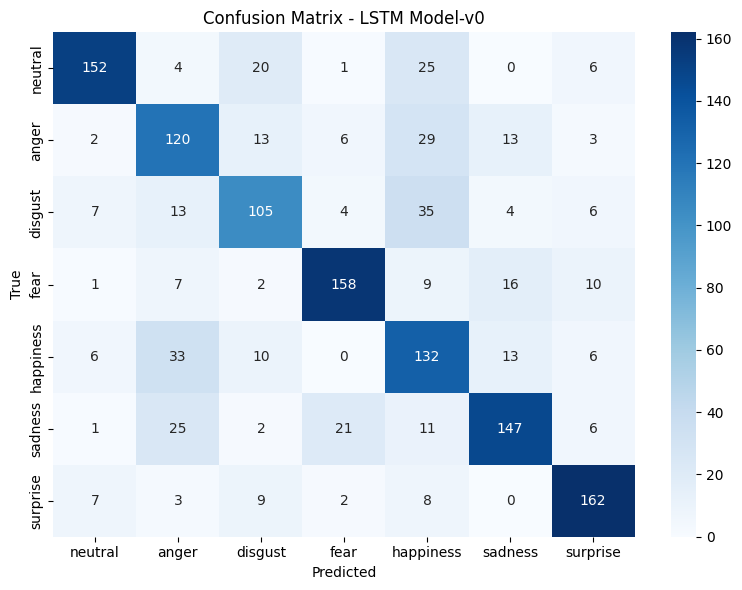

In [62]:
# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot heatmap
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[EMOTION_MAP[i] for i in range(len(EMOTION_MAP))],
            yticklabels=[EMOTION_MAP[i] for i in range(len(EMOTION_MAP))],
            ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confusion Matrix - LSTM Model-v0')
plt.tight_layout()
plt.show()

#### Two recurrent layers

In [63]:
tokens_input = Input(shape=(30,), name="tokens_input")
x = Embedding(input_dim=V+1, output_dim=128)(tokens_input)
x = LSTM(128, activation="tanh", return_sequences=True)(x)
x = LSTM(128, activation="tanh", return_sequences=False)(x)  # final hidden state
# 4. Classification head
dense = Dense(64, activation="relu", kernel_regularizer="l2")(x)
dense = Dense(128, activation="relu", kernel_regularizer="l2")(dense)
# dense = Dropout(0.4)(dense)
output = Dense(7, activation="softmax")(dense)

# 5. Build model
model = Model(inputs=tokens_input, outputs=output, name="LSTM-v1")
model.compile(optimizer=Adam(learning_rate=5e-3), loss='categorical_crossentropy', metrics=['accuracy'])

In [64]:
# Monitors the validation loss and stops after 3 epochs with no improvement
early_stopping = EarlyStopping(monitor='val_accuracy', patience=5, verbose=0, restore_best_weights=True)
with device:
    history = model.fit(
        X_train_toks, y_train,
        validation_data=(X_test_toks, y_test),
        epochs=100,
        batch_size=64,
        verbose=0,
        callbacks=[early_stopping]
    )

In [65]:
try:
    model = load_model(r"keras-models\LSTM-v1.keras")
except:
    pass

In [66]:
# Evaluate the model on the test set
loss, accuracy = model.evaluate(X_test_toks, y_test, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

Test Loss: 1.2694
Test Accuracy: 0.7825


In [67]:
# Step 1: Get predictions
y_pred_probs = model.predict(X_test_toks)

# Step 2: Convert probabilities to class labels
y_pred = np.argmax(y_pred_probs, axis=1)

# Step 3: Convert y_test if it's one-hot encoded
if y_test.ndim > 1 and y_test.shape[1] > 1:
    y_true = np.argmax(y_test, axis=1)
else:
    y_true = y_test

predictions["LSTM-v1"] = y_pred

# Step 4: Generate classification report
print(classification_report(y_true, y_pred, digits=3))

43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
              precision    recall  f1-score   support

           0      0.833     0.812     0.822       208
           1      0.617     0.753     0.678       186
           2      0.651     0.644     0.647       174
           3      0.946     0.783     0.857       203
           4      0.716     0.780     0.746       200
           5      0.846     0.826     0.836       213
           6      0.916     0.859     0.886       191

    accuracy                          0.783      1375
   macro avg      0.789     0.780     0.782      1375
weighted avg      0.794     0.783     0.786      1375



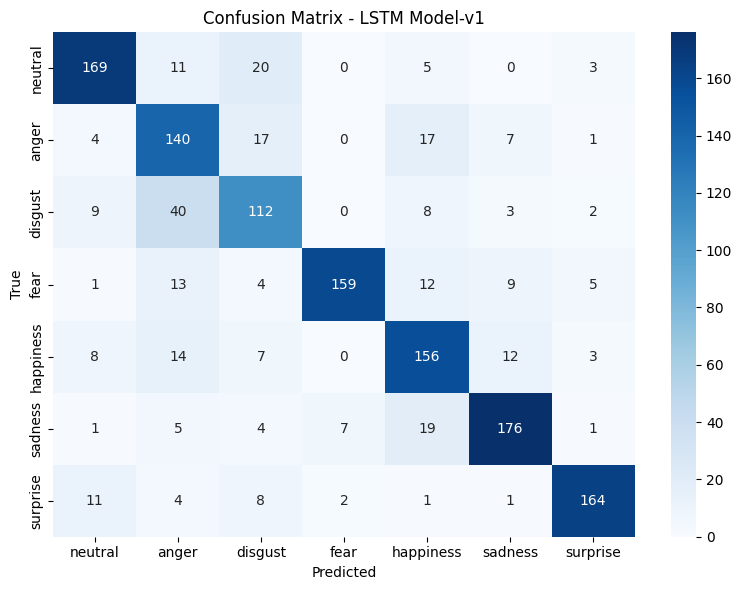

In [68]:
# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot heatmap
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[EMOTION_MAP[i] for i in range(len(EMOTION_MAP))],
            yticklabels=[EMOTION_MAP[i] for i in range(len(EMOTION_MAP))],
            ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confusion Matrix - LSTM Model-v1')
plt.tight_layout()
plt.show()

#### LSTM with additional features 

In [137]:
# 1. Text branch
tokens_input = Input(shape=(30,), name="tokens_input")
x = Embedding(input_dim=V+1, output_dim=128)(tokens_input)
x = LSTM(128, activation="tanh", return_sequences=True)(x)
x = LSTM(128, activation="tanh", return_sequences=False)(x)  # final hidden state

# 2. Extra features branch
features_input = Input(shape=(X_train_features.shape[1],), name="features_input")

# 3. Concatenate text + features
combined = Concatenate()([x, features_input])

# 4. Classification head
dense = Dropout(0.4)(combined)
dense = Dense(64, activation="relu", kernel_regularizer="l2")(dense)
dense = Dense(128, activation="relu", kernel_regularizer="l2")(dense)
output = Dense(7, activation="softmax")(dense)

# 5. Build model
model = Model(inputs=[tokens_input, features_input], outputs=output, name='LSTM-v2')
model.compile(optimizer=Adam(learning_rate=5e-3), loss='categorical_crossentropy', metrics=['accuracy'])

In [138]:
# Monitors the validation loss and stops after 3 epochs with no improvement
early_stopping = EarlyStopping(monitor='val_accuracy', patience=5, verbose=0, restore_best_weights=True)
with device:
    history = model.fit(
        [X_train_toks, X_train_features], y_train,
        validation_data=([X_test_toks, X_test_features], y_test),
        epochs=100,
        batch_size=64,
        callbacks=[early_stopping]
    )

Epoch 1/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.3645 - loss: 2.0571 - val_accuracy: 0.4465 - val_loss: 1.5653
Epoch 2/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.4514 - loss: 1.6007 - val_accuracy: 0.5462 - val_loss: 1.4512
Epoch 3/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 6s 44ms/step - accuracy: 0.4645 - loss: 1.5665 - val_accuracy: 0.4909 - val_loss: 1.4677
Epoch 4/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - accuracy: 0.5133 - loss: 1.4395 - val_accuracy: 0.5578 - val_loss: 1.3002
Epoch 5/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.6115 - loss: 1.1650 - val_accuracy: 0.6655 - val_loss: 1.0914
Epoch 6/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.7304 - loss: 0.8927 - val_accuracy: 0.7149 - val_loss: 1.0245
Epoch 7/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.7988 - loss: 0.7104 - val_accuracy: 0.7578 - val_loss: 0.9887
Epoch 8/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.8716 - loss: 0.5450 - val_accuracy: 0.

In [139]:
model.save(r"keras-models\LSTM-v2.keras")

In [140]:
try:
    model = load_model(r"keras-models\LSTM-v2.keras")
except:
    pass

In [141]:
# Evaluate the model on the test set
loss, accuracy = model.evaluate([X_test_toks, X_test_features], y_test, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

Test Loss: 0.9629
Test Accuracy: 0.7905


In [142]:
# Step 1: Get predictions
y_pred_probs = model.predict([X_test_toks, X_test_features])

# Step 2: Convert probabilities to class labels
y_pred = np.argmax(y_pred_probs, axis=1)

# Step 3: Convert y_test if it's one-hot encoded
if y_test.ndim > 1 and y_test.shape[1] > 1:
    y_true = np.argmax(y_test, axis=1)
else:
    y_true = y_test

predictions["LSTM-v2"] = y_pred

# Step 4: Generate classification report
print(classification_report(y_true, y_pred, digits=3))

43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
              precision    recall  f1-score   support

           0      0.829     0.793     0.811       208
           1      0.882     0.720     0.793       186
           2      0.610     0.799     0.692       174
           3      0.862     0.828     0.844       203
           4      0.727     0.800     0.762       200
           5      0.857     0.761     0.806       213
           6      0.828     0.832     0.830       191

    accuracy                          0.791      1375
   macro avg      0.799     0.790     0.791      1375
weighted avg      0.803     0.791     0.793      1375



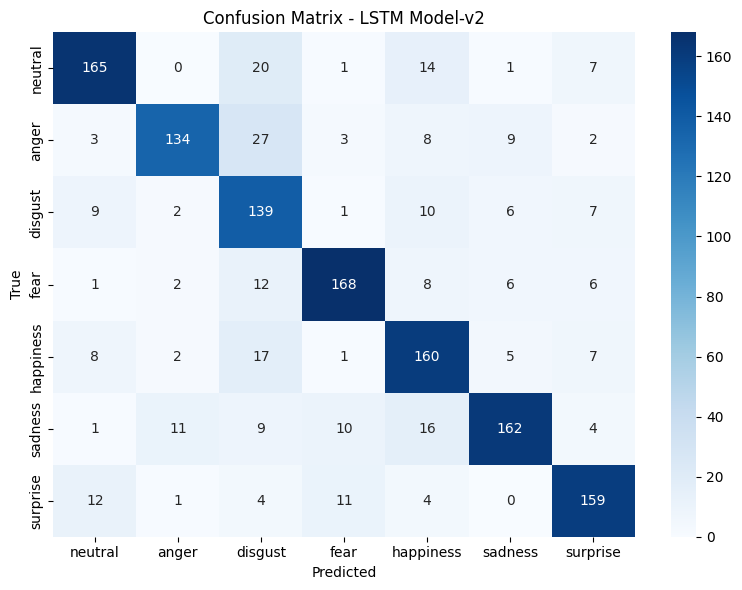

In [143]:
# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot heatmap
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[EMOTION_MAP[i] for i in range(len(EMOTION_MAP))],
            yticklabels=[EMOTION_MAP[i] for i in range(len(EMOTION_MAP))],
            ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confusion Matrix - LSTM Model-v2')
plt.tight_layout()
plt.show()

In [94]:
TRUE_KERAS = y_true
KERAS_TEST = X_test

In [144]:
# Define which models use sklearn-style data and which use keras-style data
sklearn_models = {"Logistic Regression", "Naive Bayes", "SVC"}
keras_models = {"SimpleRNN-v0", "SimpleRNN-v1", "LSTM-v0", "LSTM-v1", "LSTM-v2"} 

for model_name, y_pred in predictions.items():
    if model_name in sklearn_models:
        f1 = f1_score(TRUE_SKLEARN, y_pred, average='weighted')  # sklearn y_test
    elif model_name in keras_models:
        f1 = f1_score(TRUE_KERAS, y_pred, average='weighted')  # keras y_test_seq
    else:
        raise ValueError(f"Unknown model name: {model_name}")
    
    print(f"The {model_name} model yielded a weighted F1 score of: {f1:.3f}")


The Logistic Regression model yielded a weighted F1 score of: 0.220
The Naive Bayes model yielded a weighted F1 score of: 0.145
The SVC model yielded a weighted F1 score of: 0.189
The SimpleRNN-v0 model yielded a weighted F1 score of: 0.553
The SimpleRNN-v1 model yielded a weighted F1 score of: 0.597
The LSTM-v0 model yielded a weighted F1 score of: 0.713
The LSTM-v1 model yielded a weighted F1 score of: 0.786
The LSTM-v2 model yielded a weighted F1 score of: 0.793


In [145]:
def error_analysis(predictions, model_group, X_test_data, y_true, label_map):
    results = {}
    all_errors = []

    for model_name in model_group:
        if model_name not in predictions:
            continue

        y_pred = predictions[model_name]

        # Convert both to numpy arrays for safe comparison
        y_true_np = y_true.to_numpy() if isinstance(y_true, pd.Series) else np.array(y_true)
        y_pred_np = y_pred.to_numpy() if isinstance(y_pred, pd.Series) else np.array(y_pred)

        # Find mismatches
        mismatches = np.where(y_true_np != y_pred_np)[0]

        mismatched_examples = []
        for i in mismatches[:10]:
            # X_test_data row
            x_row = X_test_data.iloc[i] if isinstance(X_test_data, pd.DataFrame) else X_test_data[i]
            # Convert labels to human-readable names
            true_val = label_map[y_true_np[i]]
            pred_val = label_map[y_pred_np[i]]
            mismatched_examples.append((x_row, true_val, pred_val))

        results[model_name] = {
            "num_errors": len(mismatches),
            "total": len(y_true),
            "error_rate": len(mismatches) / len(y_true),
            "mismatched_indices": mismatches,
            "mismatched_examples": mismatched_examples
        }

        # Aggregate common mistakes using label names
        for i in mismatches:
            true_val = label_map[y_true_np[i]]
            pred_val = label_map[y_pred_np[i]]
            all_errors.append((true_val, pred_val))

    # Aggregate common mistakes
    most_common_errors = Counter(all_errors).most_common(10)

    return results, most_common_errors

### Error analysis on Scikit-learn models and Keras models

#### *Scikit-learn*

- **Logistic Regression**
    - Even when applying multiple iterations and improvements to Logistic Regression, the highest F1-score achieved was only around 25% for 6 classes. 

    - Looking at the confusion matrix of Logistic Regression, it is doing somewhat decent on classifying neutral, disgust and happiness. 

    - It is doing particularly bad on fear, where it only predicted one instance of fear correctly and most of the fear class was predicted into ___neutral, anger, disgust and surprise___

- **Naive Bayes**
    - Same case as with Logistic Regression. After many interations the best achieved F1-score was 27%.

    - This model is doing well on neutral, happiness and then somewhat good on disgust and fear. 

    - The biggest issue is, that it predcts everything as neutral for most cases, with many sadness classes being predicted as neutral and none as sadness

- **Support Vector Machine**
    - Support Vector Machine was achieving the worst reuslts among these three, achieving only 22% F1-score at best. 

    - This model is doing the best on happiness. It classifies happiness 49 out of 70. Also it is doing somewhat good on disgust.

    - But as is was case with the Logistic Regression, it is doing really bad on fear and sadness.

*Scikit-Learn overall statistic*

All of the models have more than **70%** error rate. The most troubling class is happiness with having most errors in ***surprise, anger, sadness and neutral***. 

Next problematic class is neutral. Not as problematic as happiness, but it is right behind it. This may suggest that the models fail to correctly distinguish fear and anger from neutral, even though when these should be clearly separate. We come to the conclusion, that scikit-learn models are not suitable for this task

#### *Keras*

- **RNN Model** 

    - Two models were constructed using the Keras functional API around the SimpleRNN recurrent layer. The first model only had one recurrent layer where the second had two recurrent layers. The assumption was that two recurrent layers would better capture the patterns language patterns in the training data, being able to better differentiate between emotions. 

    - The model with two recurrent layers proved our assumption correct by performing better than the model with only one recurrent layer. The first model, named `"SimpleRNN-v0"` yielded a weighted F1 score of: 0.553 or 55.3%. The model with two recurrent layers, named `"SimpleRNN-v1"` yielded a weighted F1 score of: 0.597 or 59.7%.The performance jump was significant, the second model performing better by about 5% when looking at the wighted F1 score metric.

    - After experiments with layer normalization, droupout rates and learning rates, we identified these as being the best parameters for the SimpleRNN models: lr=1e-4, kernel_regularizer="l2" for the dense layers, batch_size=64, 0.4 dropout layer before the classification head. 

    - The weighted F1 score of about 60% showed that with proper parameters and architecture, the model can differentiate between emotions.

    - Its best performance is on neutral where the F1-score was around 79%. The rest of the emotions had a score in a range of 51-64%. 

    - The worst performing classess were ***anger, happiness and disgust***. **Anger** had many of its classes predicted as disgust or sadness. **Disgust** was distributed into sadness, anger and neutral. Finally **happiness** had the most wrong classifications in sadness and all the other classess had similar wrong distribution.  


- **LSTM Model**
    - Same as with the SimpleRNN layer, two models were constructed using the Keras functional API for the LSTM layer. The first model only had one recurrent layer where the second had two recurrent layers. The assumption was that two recurrent layers would better capture the patterns language patterns in the training data, being able to better differentiate between emotions. 

    - The model with two recurrent layers proved our assumption correct again by performing better than the model with only one recurrent layer.

    - The first model, named `LSTM-v0"` yielded a weighted F1 score of: 0.713 or 71.3%. The model with two recurrent layers, named `"LSTM-v1"` yielded a weighted F1 score of: 0.786 or 78.6%. The second model performed better by about 7% when looking at the wighted F1 score metric. 

    - After experiments with layer normalization, droupout rates and learning rates, we identified these as being the best parameters for the LSTM models: lr=5e-3, kernel_regularizer="l2" for the dense layers, batch_size=64. 

    - The weighted F1 score of approximately 80% shows the model can better understand the language patterns in the traing data and can differentiate quite well between emotions. This is the first model that got us over the 75% F1-score needed as a minimum requirement.

    -  Overall the best performance is on sadness. Other good performing are neutral, surprise, fear and happiness. 

    - Although the overall results are good, there are still some issues. This model is struggling with correctly labeling disgust. It mistakes the class with anger the most. This goes both ways as anger also gets classified as disgust. These two sentiments are not always easy to differentiate between but it is still something to be taken into consideration. 

*Keras overall statistics* 

After many many attempts and experiments the best F1-scores reached were 60% for RNN and 79% for LSTM. Most errors were made with disgust being classified as anger with around 100 errors.

There are also opposite classes that get missclasified between eachother. Sadness - Happiness with most of these misclassifications (67 errors). By focusing on LSTM model and correcting these mistakes, we could be reaching even higher scores. We might consider looking into LSTM when it comes to emotion classification system. 


In [146]:
sk_results, sk_common_errors = error_analysis(predictions, sklearn_models, SK_TEST, TRUE_SKLEARN, EMOTION_MAP)
keras_results, keras_common_errors = error_analysis(predictions, keras_models, KERAS_TEST, TRUE_KERAS, EMOTION_MAP)

# Display
print("Scikit-learn models error stats:")
for model, stats in sk_results.items():
    print(f"{model}: {stats['num_errors']} errors out of {stats['total']} ({stats['error_rate']:.2%})")

print("\nMost common sklearn mistakes (true → predicted):")
for item in sk_common_errors:
    print(item)

print("\nKeras models error stats:")
for model, stats in keras_results.items():
    print(f"{model}: {stats['num_errors']} errors out of {stats['total']} ({stats['error_rate']:.2%})")

print("\nMost common keras mistakes (true → predicted):")
for item in keras_common_errors:
    print(item)


Scikit-learn models error stats:
Logistic Regression: 723 errors out of 967 (74.77%)
Naive Bayes: 761 errors out of 967 (78.70%)
SVC: 741 errors out of 967 (76.63%)

Most common sklearn mistakes (true → predicted):
(('surprise', 'happiness'), 159)
(('fear', 'neutral'), 152)
(('sadness', 'neutral'), 135)
(('fear', 'anger'), 113)
(('disgust', 'neutral'), 111)
(('surprise', 'neutral'), 105)
(('anger', 'neutral'), 100)
(('sadness', 'anger'), 98)
(('happiness', 'neutral'), 94)
(('disgust', 'anger'), 91)

Keras models error stats:
LSTM-v1: 299 errors out of 1375 (21.75%)
LSTM-v0: 399 errors out of 1375 (29.02%)
SimpleRNN-v1: 555 errors out of 1375 (40.36%)
SimpleRNN-v0: 615 errors out of 1375 (44.73%)
LSTM-v2: 288 errors out of 1375 (20.95%)

Most common keras mistakes (true → predicted):
(('anger', 'disgust'), 104)
(('neutral', 'disgust'), 100)
(('disgust', 'anger'), 95)
(('fear', 'anger'), 88)
(('sadness', 'happiness'), 83)
(('sadness', 'fear'), 82)
(('happiness', 'surprise'), 77)
(('sadne